In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [2]:
sklearn. __version__

'1.7.2'

## Data preparation

In [3]:
# Dataset loading
raw_df = pd.read_csv('customer_segmentation_dataset.csv')

In [4]:
raw_df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,PreferredCategory,CustomerID,Gender
0,52.704543,60215.004541,71.054078,5.156217,100.408343,1357.513328,Clothing,1117,Female
1,21.918173,49322.316537,70.683512,3.507173,88.413767,659.809063,Luxury,1369,Male
2,34.672262,25647.414471,34.832829,1.270919,27.656651,61.248931,Groceries,423,Male
3,31.112305,30079.037721,37.244059,1.200491,29.166199,165.077975,Groceries,414,Male
4,36.825627,32691.620112,25.714151,1.448637,24.518336,83.783270,Groceries,452,Female


In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1500 non-null   float64
 1   AnnualIncome       1500 non-null   float64
 2   SpendingScore      1500 non-null   float64
 3   PurchaseFrequency  1500 non-null   float64
 4   AverageBasketSize  1500 non-null   float64
 5   LoyaltyPoints      1500 non-null   float64
 6   PreferredCategory  1500 non-null   object 
 7   CustomerID         1500 non-null   int64  
 8   Gender             1500 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 105.6+ KB


In [6]:
raw_df.describe()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,CustomerID
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,37.280831,67264.892504,67.323610,6.379343,120.209451,1615.478800,750.500000
std,10.261314,34264.393922,23.568888,4.016314,71.351200,1480.107927,433.157015
min,10.578378,16576.059764,20.013068,1.000061,2.777223,0.298969,1.000000
25%,29.805078,37344.859024,55.056564,2.998994,52.789230,499.107283,375.750000
50%,37.500455,58596.040847,74.839231,5.493192,116.193326,1000.518510,750.500000
75%,44.797507,93588.656419,84.404828,8.504391,169.635239,2249.961077,1125.250000
max,64.073272,150788.808085,99.958682,14.997069,359.655378,4995.641711,1500.000000


### Create a copy of the data for processing and model training

#### We will keep the raw data for assessment later

In [7]:
#Duplicate the raw data
df = raw_df.copy()

In [8]:
#crosscheck the dulicate copy
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,PreferredCategory,CustomerID,Gender
0,52.704543,60215.004541,71.054078,5.156217,100.408343,1357.513328,Clothing,1117,Female
1,21.918173,49322.316537,70.683512,3.507173,88.413767,659.809063,Luxury,1369,Male
2,34.672262,25647.414471,34.832829,1.270919,27.656651,61.248931,Groceries,423,Male
3,31.112305,30079.037721,37.244059,1.200491,29.166199,165.077975,Groceries,414,Male
4,36.825627,32691.620112,25.714151,1.448637,24.518336,83.783270,Groceries,452,Female


In [9]:
#check for missing values

df.isnull().sum()

Age                  0
AnnualIncome         0
SpendingScore        0
PurchaseFrequency    0
AverageBasketSize    0
LoyaltyPoints        0
PreferredCategory    0
CustomerID           0
Gender               0
dtype: int64

#### Remove Unnecessary columns 

In [10]:
df.drop(['CustomerID', 'LoyaltyPoints'], axis = 1, inplace=True)

In [11]:
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,52.704543,60215.004541,71.054078,5.156217,100.408343,Clothing,Female
1,21.918173,49322.316537,70.683512,3.507173,88.413767,Luxury,Male
2,34.672262,25647.414471,34.832829,1.270919,27.656651,Groceries,Male
3,31.112305,30079.037721,37.244059,1.200491,29.166199,Groceries,Male
4,36.825627,32691.620112,25.714151,1.448637,24.518336,Groceries,Female


### Explore numerical columns

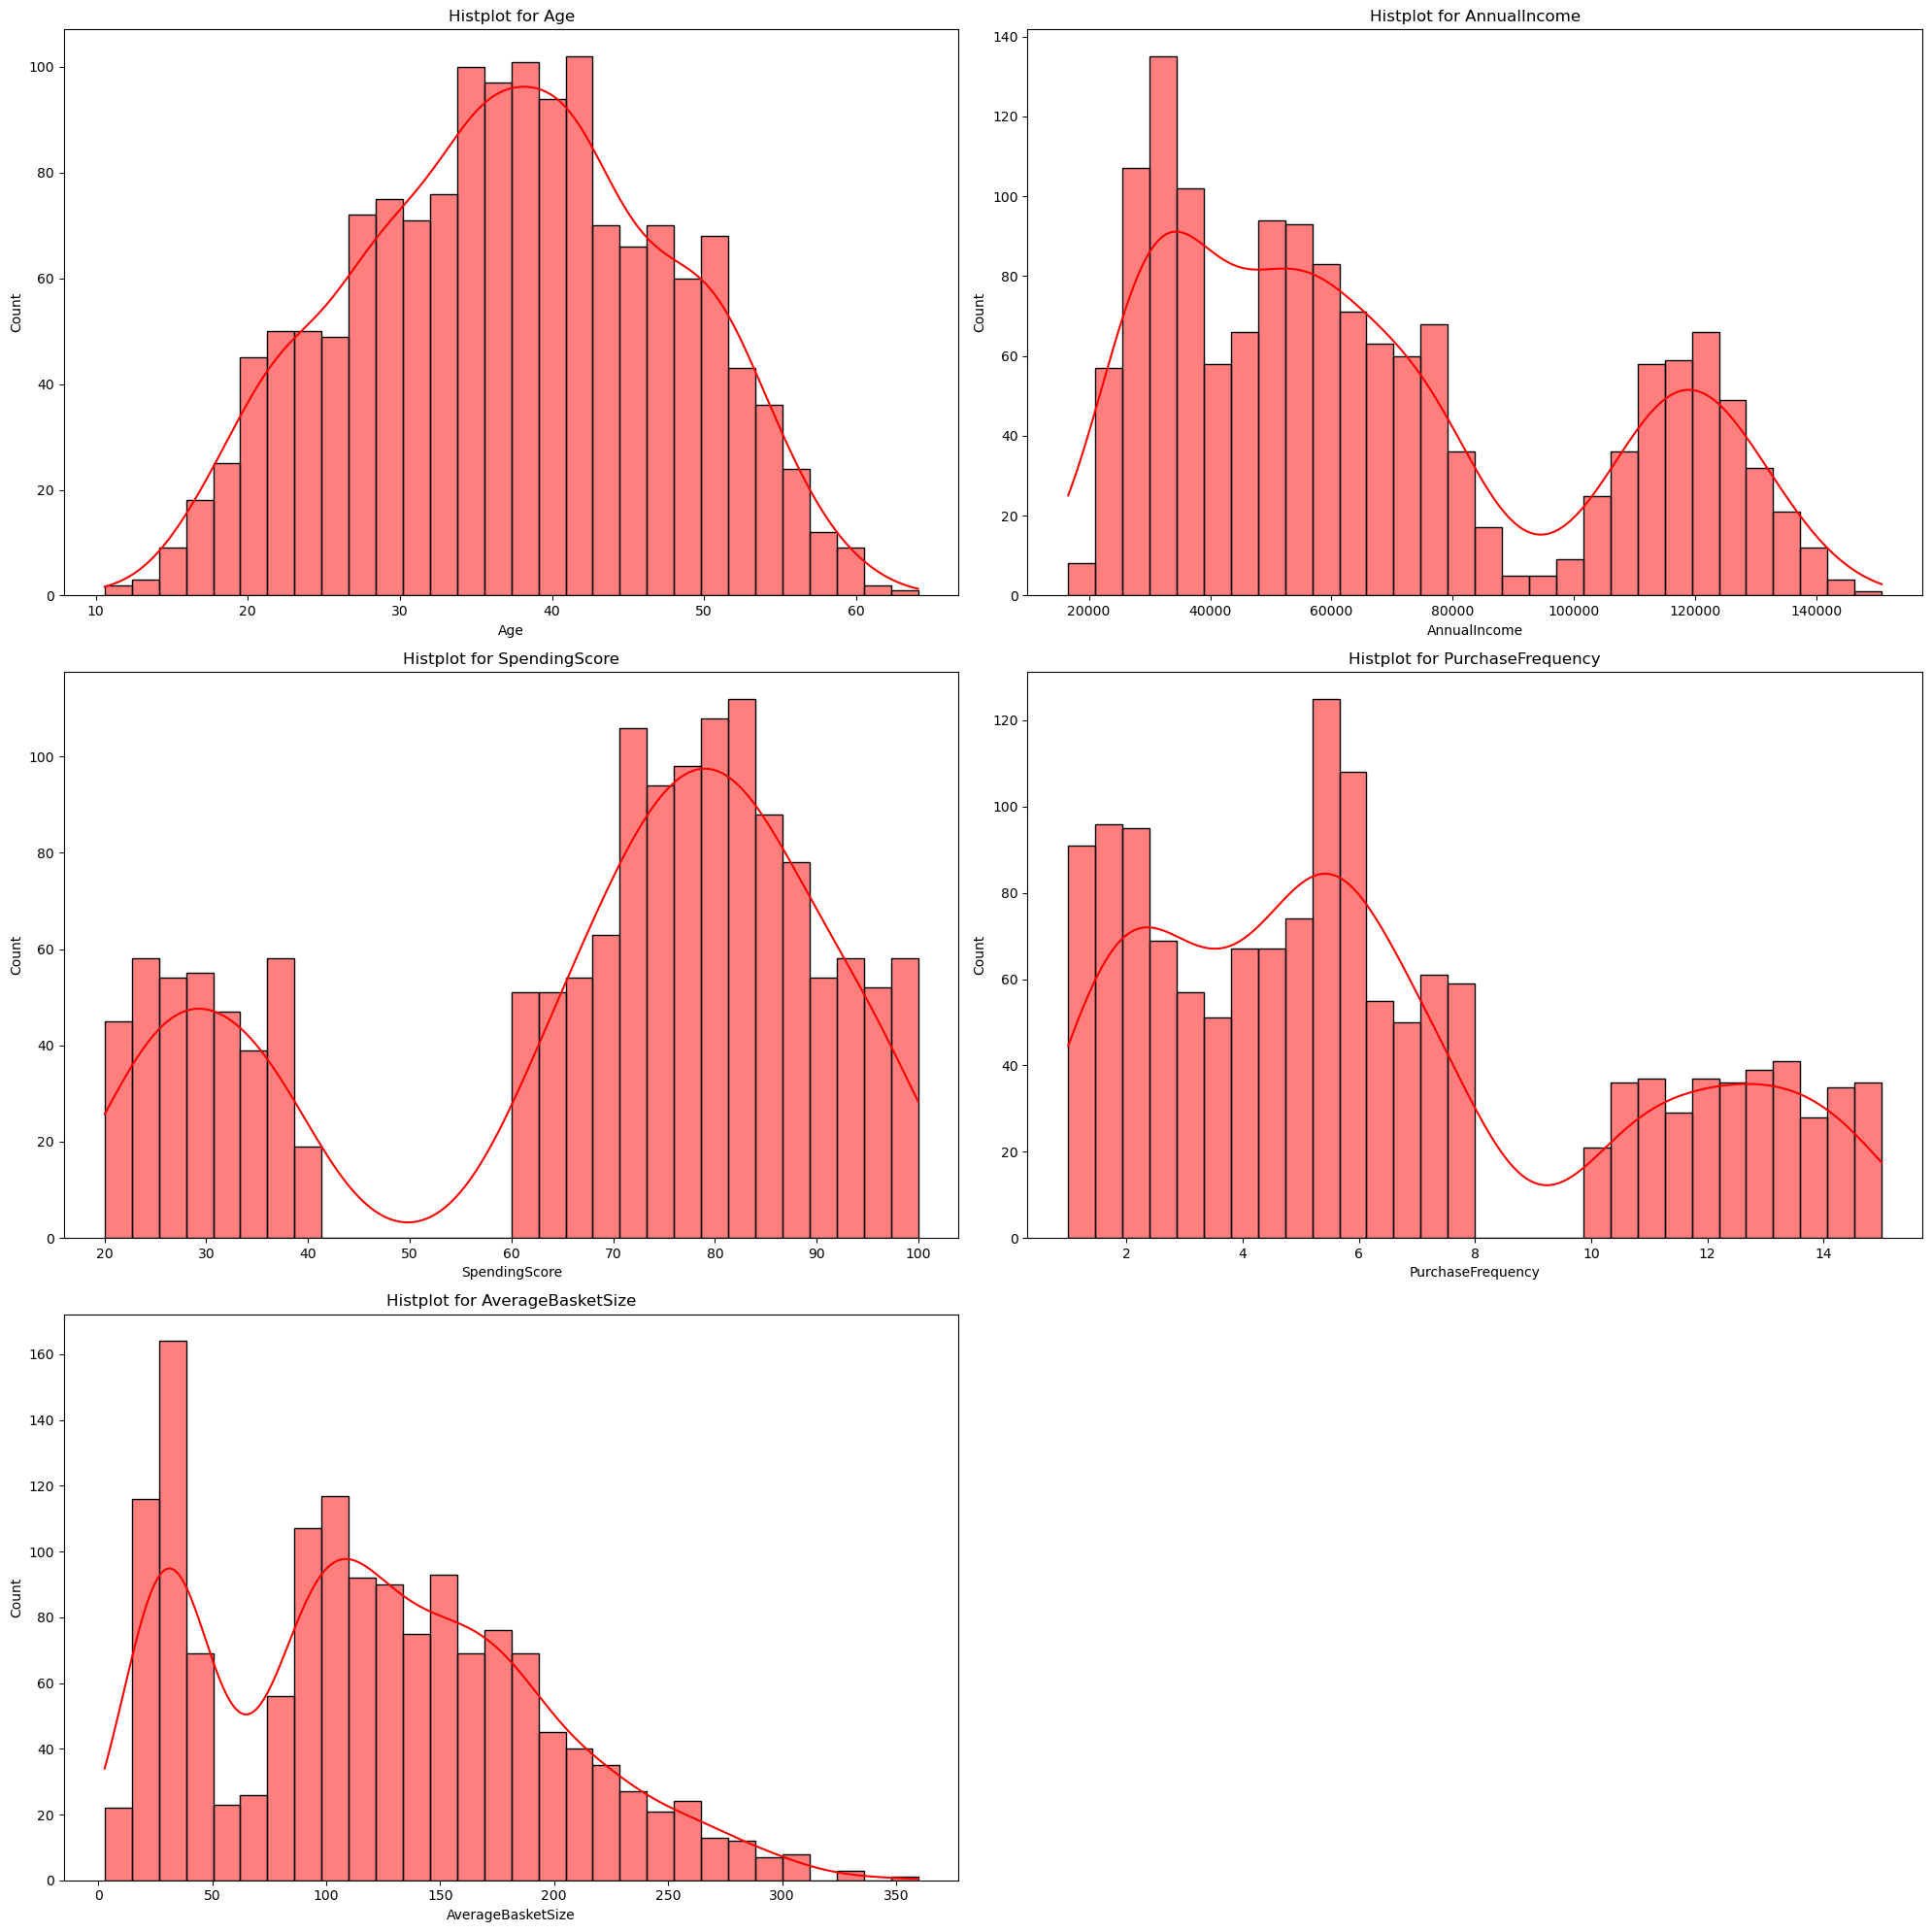

In [12]:
### Explore numerical columns
num_col = df.select_dtypes(include="number").columns
plt.figure(figsize=(20,20))

for idx, col in enumerate(num_col, 1):
    plt.subplot(3,2,idx)
    sns.histplot(df[col], bins=30, color="red", kde=True)
    #ax[idx].set_title(f"Histplot for {col}")
    plt.title(f"Histplot for {col}")
plt.tight_layout()
plt.show()

### Feature Scaling
#### Scale numerical features for clustering

In [13]:
#import lib.

from sklearn.preprocessing import StandardScaler

In [14]:
# apply scaler
scaler = StandardScaler()
df[num_col] = scaler.fit_transform(df[num_col])

In [15]:
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,1.503594,-0.205818,0.158332,-0.304641,-0.277609,Clothing,Female
1,-1.497643,-0.523825,0.142604,-0.715364,-0.445771,Luxury,Male
2,-0.254299,-1.215003,-1.379005,-1.272343,-1.297577,Groceries,Male
3,-0.601344,-1.085624,-1.276665,-1.289884,-1.276413,Groceries,Male
4,-0.044376,-1.009351,-1.766029,-1.228079,-1.341576,Groceries,Female


### Encode Categorical Data

#### Convert gender and preferred category into numerical representation

In [16]:
# import libraries
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoders = {}  # Dictionary to store encoders

categorical_columns = ['PreferredCategory', 'Gender']
for column_name in categorical_columns:
    le = LabelEncoder()
    df[column_name] = le.fit_transform(df[column_name])
    label_encoders[column_name] = le  # Save the encoder

In [18]:
df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,1.503594,-0.205818,0.158332,-0.304641,-0.277609,0,0
1,-1.497643,-0.523825,0.142604,-0.715364,-0.445771,3,1
2,-0.254299,-1.215003,-1.379005,-1.272343,-1.297577,2,1
3,-0.601344,-1.085624,-1.276665,-1.289884,-1.276413,2,1
4,-0.044376,-1.009351,-1.766029,-1.228079,-1.341576,2,0


In [19]:
# import lib

from sklearn.cluster import KMeans

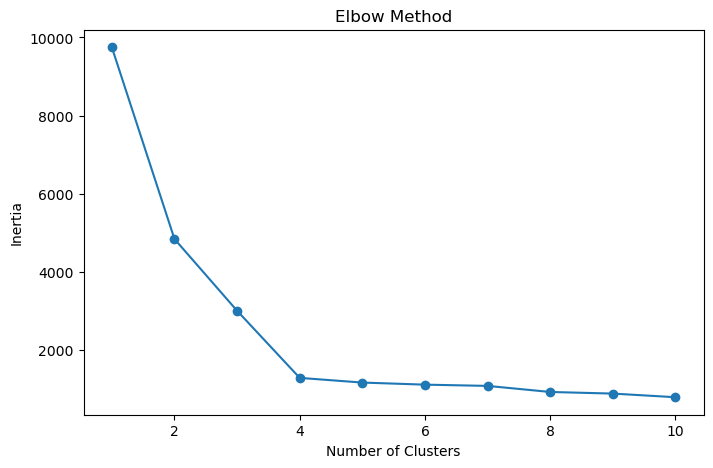

In [20]:
# Elbow method

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Plot inertia values
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

#### Silhouette Score

In [21]:
#import lib

from sklearn.metrics import silhouette_score

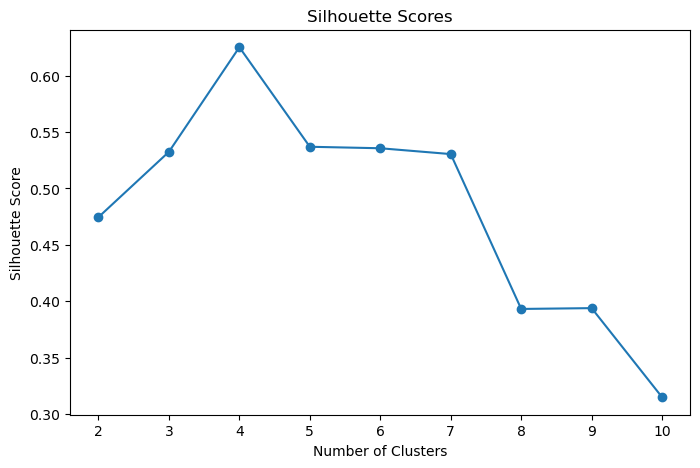

In [22]:
# silhouette method

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    silhouette_scores.append(silhouette_score(df, kmeans.labels_))

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

## Applying KMeans Clustering

The optimal num is 4 Clusters (based on Elbow and Silhouette)

In [23]:
# Apply K-Means clustering

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

kmeans.fit(df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [24]:
raw_df['cluster_km']= kmeans.labels_

In [25]:
raw_df.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,PreferredCategory,CustomerID,Gender,cluster_km
0,52.704543,60215.004541,71.054078,5.156217,100.408343,1357.513328,Clothing,1117,Female,3
1,21.918173,49322.316537,70.683512,3.507173,88.413767,659.809063,Luxury,1369,Male,2
2,34.672262,25647.414471,34.832829,1.270919,27.656651,61.248931,Groceries,423,Male,1
3,31.112305,30079.037721,37.244059,1.200491,29.166199,165.077975,Groceries,414,Male,1
4,36.825627,32691.620112,25.714151,1.448637,24.518336,83.783270,Groceries,452,Female,1


### Apply Hierarchichal Clustering

In [26]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

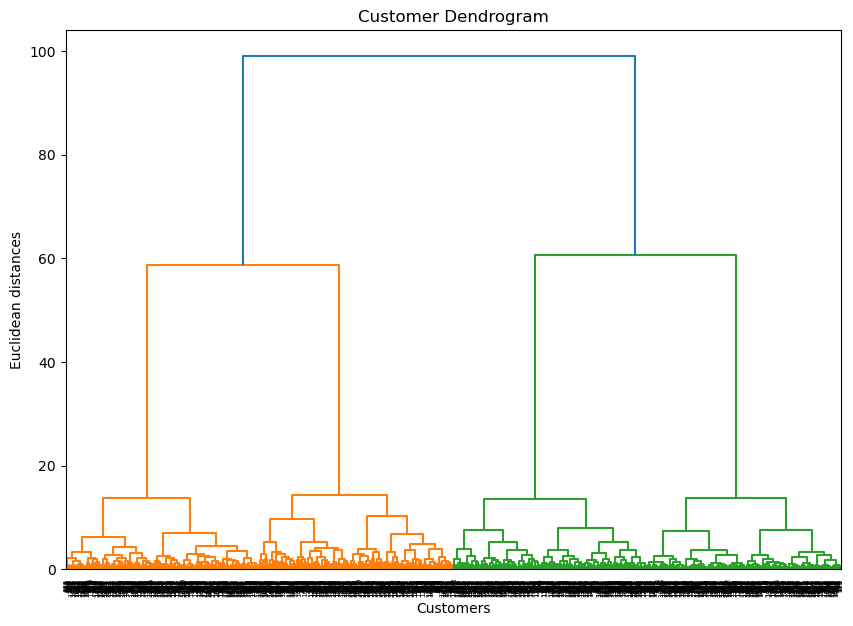

In [27]:
# Plot the dendrogram to find the optimal number of clusters

plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(df, method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [28]:
#Modelling
agg_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agg_clustering.fit_predict(df)

# Add the cluster labels to the original DataFrame
raw_df['Cluster_hc'] = agg_clustering.labels_

raw_df.head()  

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,PreferredCategory,CustomerID,Gender,cluster_km,Cluster_hc
0,52.704543,60215.004541,71.054078,5.156217,100.408343,1357.513328,Clothing,1117,Female,3,3
1,21.918173,49322.316537,70.683512,3.507173,88.413767,659.809063,Luxury,1369,Male,2,2
2,34.672262,25647.414471,34.832829,1.270919,27.656651,61.248931,Groceries,423,Male,1,1
3,31.112305,30079.037721,37.244059,1.200491,29.166199,165.077975,Groceries,414,Male,1,1
4,36.825627,32691.620112,25.714151,1.448637,24.518336,83.783270,Groceries,452,Female,1,1


In [29]:
# check if there is a row where HC is not the same

raw_df[~(raw_df["cluster_km"] == raw_df["Cluster_hc"])] 

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,LoyaltyPoints,PreferredCategory,CustomerID,Gender,cluster_km,Cluster_hc


### Model Interpretation
Visualize relationships between key variables and the different clusters to interprete the model.The raw data is used

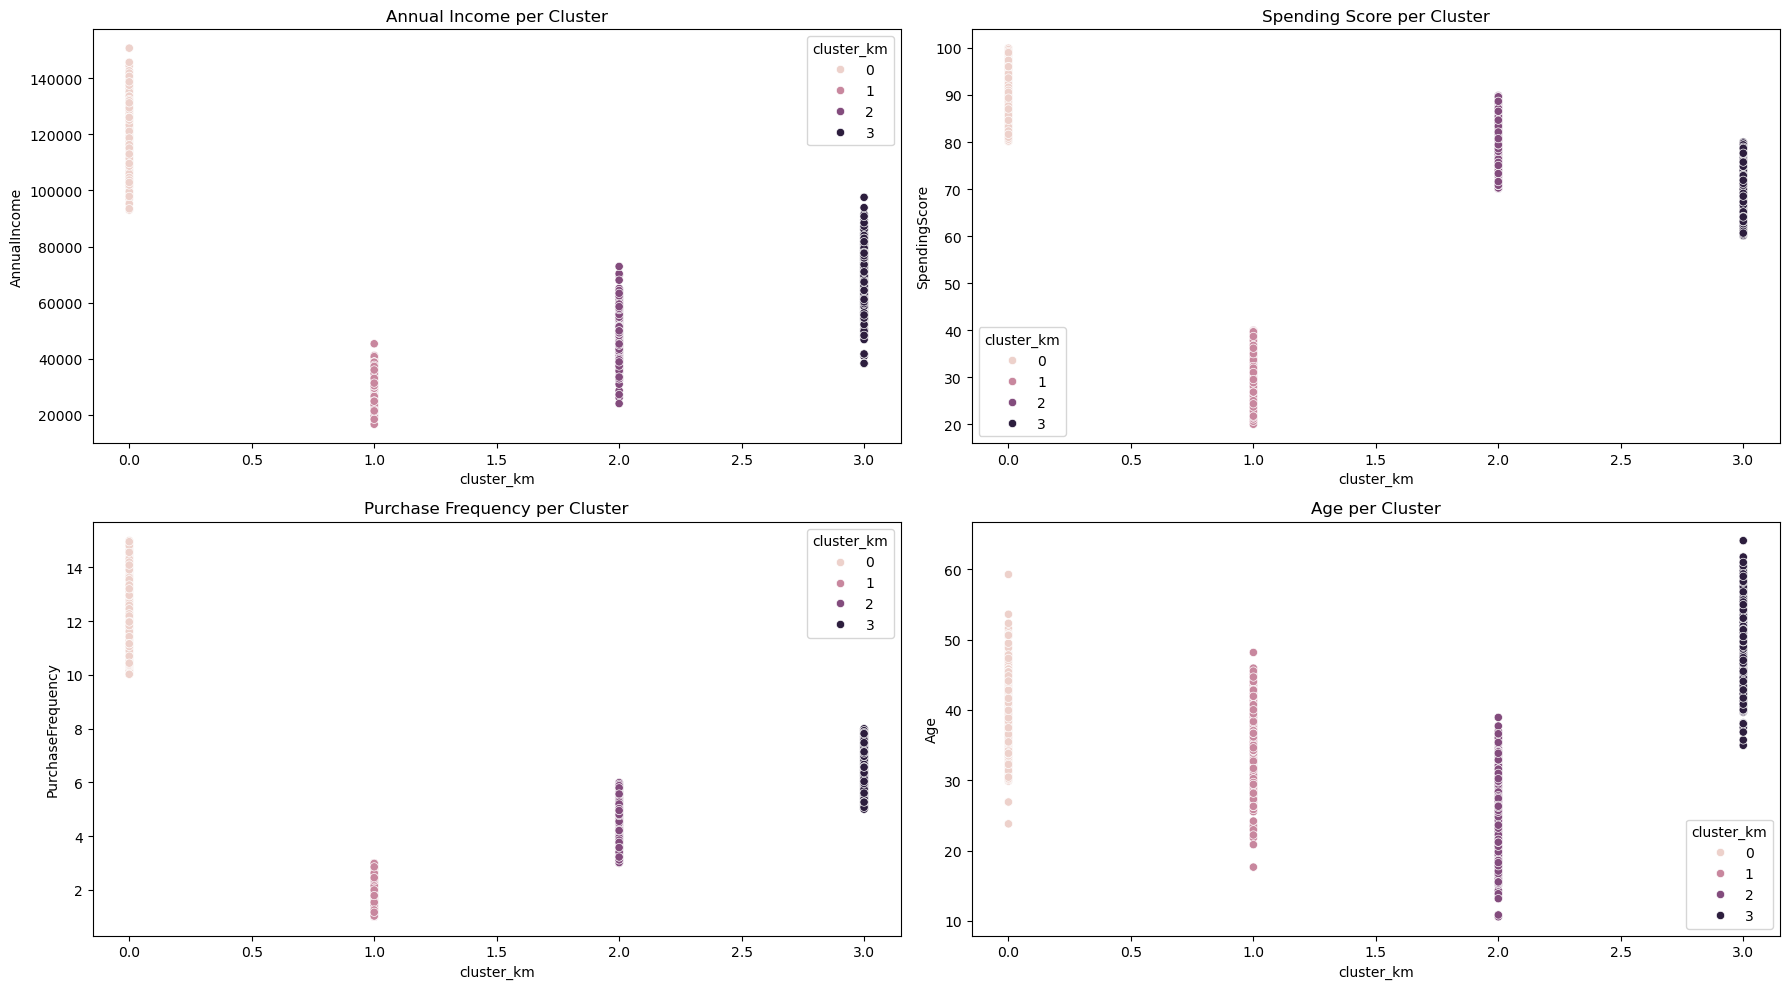

In [30]:
plt.figure(figsize = (18,10))
plt.subplot(2,2,1)
sns.scatterplot(x="cluster_km", y='AnnualIncome', hue="cluster_km", data=raw_df)
plt.title('Annual Income per Cluster')

plt.subplot(2,2,2)
sns.scatterplot(x="cluster_km", y='SpendingScore', hue="cluster_km", data=raw_df)
plt.title('Spending Score per Cluster')

plt.subplot(2,2,3)
sns.scatterplot(x="cluster_km", y='PurchaseFrequency',hue="cluster_km",  data=raw_df)
plt.title('Purchase Frequency per Cluster')

plt.subplot(2,2,4)
sns.scatterplot(x="cluster_km", y='Age',hue="cluster_km",  data=raw_df)
plt.title('Age per Cluster')

plt.tight_layout()
plt.show()

# Interpretation

## Annual Income
#### Cluster 0 are high-income earners between 90k and 150k
#### Cluster 1 are low-income earners between 20k and 50k
#### Cluster 2 are higher than low-income earners between >20k and less than 80k
#### Cluster 3 are higher than cluster 2 earners and between > 40k and less than 100k

## Spending 
#### Cluster 0 are high spenders
#### Cluster 1 are low spenders
#### Cluster 2 spend lower than cluster 0 but higher than the other two clusters. 
#### Cluster 3 spend higher than cluster 1 but lower than cluster

## Purchase frequency
#### Cluster 0 are frequent purchasers
#### Cluster 1 are have the lowest purchase frequency, followed by cluster 2 and lastly cluster 3. 


## Age
#### Cluster 0 are between 25 and 60 years of age. The difference in age between all clusters is not significant and it is afe to say that age does not have a lot of effect. 

# Insights

#### Cluster 0: High-income, high-spending frequent buyers (Likely Premium customers).
#### Cluster 1: Low-income, low-spending infequent buyers (Price-sensitive customers).
#### Cluster 2: Young, high-spending occassional buyers (Luxury-oriented buyers).
#### Cluster 3: Mid-income, moderate-spending regular buyers (Consistent shoppers).

# Recommendations

#### Cluster 0 - Premium customers
    - Run a high-touch loyalty tier (early access, dedicated service); do not discount them.
    - Personalise replenishment and exclusive drops from their purchase history.
    - Judge success on repeat rate and margin, not on promotional volume.

#### Cluster 1 - Price-sensitive customers
    - Lead with entry-price lines, bundles, and tightly capped, time-limited offers.
    - Keep acquisition and service cheap; do not fund premium perks for this group.
    - Track profit after discounts and returns, and stop offers that only sell at deep cut.

#### Cluster 2 - Luxury-oriented occasional buyers
    - Market to occasions and brand heat (drops, collaborations, gifting), not everyday deals.
    - After a large purchase, push a second smaller basket—not an immediate sale.
    - Aim to convert them into frequent premium buyers; measure time to second order.

#### Cluster 3 - Consistent shoppers
    - Make repurchase automatic: subscriptions, reminders, simple cashback.
    - Centre the range on reliable bestsellers and fair, predictable value.
    - Protect annual margin and purchase frequency; do not over-trade them into luxury.

In [31]:
import pickle

# save the model, scaler and encoder
with open('kmeans_model.pkl', 'wb') as model_file:
    pickle.dump(kmeans, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('label_encoders.pkl', 'wb') as encoder_file:
    pickle.dump(label_encoders, encoder_file)

# Demo (Real-time use of the clustering system)

In [32]:
### Load the saved model, scaler, and encoder
with open('kmeans_model.pkl', 'rb') as model_file:
    kmeans = pickle.load(model_file)

with open('scaler.pkl', 'rb') as scaler_file:
    scaler = pickle.load(scaler_file)

with open('label_encoders.pkl', 'rb') as encoders_file:
    label_encoders = pickle.load(encoders_file)

In [40]:
#New customer example
new_customer = {
    'Age' : 30,
    'AnnualIncome' : 50000,
    'SpendingScore' : 75,
    'PurchaseFrequency' : 4,
    'AverageBasketSize' : 120,
    'PreferredCategory' : 'Luxury',
    'Gender': 'Male'
}

In [41]:
# Conver new_customer details into a dataframe
new_customer_df = pd.DataFrame([new_customer])

In [42]:
new_customer_df

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,30,50000,75,4,120,Luxury,Male


In [43]:
#Apply Label encoder
categorical_columns = ['PreferredCategory', 'Gender']
for col in categorical_columns:
    le = label_encoders[col]
    new_customer_df[col] = le.transform(new_customer_df[col])

In [44]:
new_customer_df

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,30,50000,75,4,120,3,1


In [56]:
# Scale numerical column
numerical_columns = ['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency', 'AverageBasketSize']
new_customer_df[numerical_columns] = scaler.transform(new_customer_df[numerical_columns])

In [61]:
new_customer_df

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AverageBasketSize,PreferredCategory,Gender
0,-3.703549,-1.963783,-2.843585,-1.736489,-1.68536,3,1


In [62]:
selected_columns = ['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency', 
                    'AverageBasketSize', 'PreferredCategory', 'Gender']

In [63]:
#predict the cluster of the new dataset
x_new = new_customer_df[selected_columns]

new_customer_cluster = kmeans.predict(x_new)

In [65]:
print(f"The new customer belongs to Cluster {new_customer_cluster[0]}.")

The new customer belongs to Cluster 1.
